In [144]:
import json
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import numpy as np

In [145]:
pretty_labels = {
    # Task types
    'uptake': 'Gas uptake',
    'heat': 'Heat of adsorption',
    'henry': 'Henry coefficient',
    'selectivity': 'Selectivity',
    # Models
    'cgcnn': 'CGCNN',
    'moformer': 'MOFormer',
    'pmtransformer': 'PMTransformer',
    'spbnet': 'SpbNet',
    'intellipore': 'IntelliPore',
    # Datasets,
    'hmof': 'hMOF',
    'hmofheat': 'hMOF',
    'cof': 'hCOF',
    'zeolite': 'hZEO',
    'ppn': 'hPPN',
    'ch4n2': 'CoRE 2019',
    'c3h6c3h8coremof': 'CoRE 2019',
    'corecof': 'CoRE COF',
    'uo_water': 'UO',
    # hmofheat
    'H2-77K-2bar': 'H$_2$ heat of adsorption at 77 K and 2 bar (MOFs)',
    'CO2-298K-2.5bar': 'CO$_2$ heat of adsorption at 298 K and 2.5 bar (MOFs)',
    # hmof
    'H2-77-2': 'H$_2$ uptake at 77 K and 2 bar (MOFs)',
    'CO2-298-2.5': 'CO$_2$ uptake at 298 K and 2.5 bar (MOFs)',
    'CH4-298-2.5': 'CH$_4$ uptake at 298 K and 2.5 bar (MOFs)',
    'N2-298-0.9': 'N$_2$ uptake at 298 K and 0.9 bar (MOFs)',
    'Xe-273-10': 'Xe binary uptake at 273 K and 10 bar (MOFs)',
    'Kr-273-10': 'Kr binary uptake at 273 K and 10 bar (MOFs)',
    # cof
    'lowbar': 'CH$_4$ uptake at 298 K and 5.8 bar (COFs)',
    'highbar': 'CH$_4$ uptake at 298 K and 65 bar (COFs)',
    # ppn
    '1bar': 'CH$_4$ uptake at 298 K and 1 bar (PPNs)',
    '65bar': 'CH$_4$ uptake at 298 K and 65 bar (PPNs)',
    # zeolite
    'unitless_KH': ' CH$_4$ (unitless) Henry coefficient at 298 K (ZEOs)',
    'heat_of_adsorption': 'CH$_4$ isosteric heat of adsorption at 298 K (ZEOs)',
    # c3h6c3h8coremof
    'C3H6_loadings': 'C$_3$H$_6$ binary uptake at 298 K and 1 bar (MOFs)',
    'C3H8_loadings': 'C$_3$H$_8$ binary uptake at 298 K and 1 bar (MOFs)',
    'C3H8_C3H6_Selectivity_1bar': 'C$_3$H$_8$/C$_3$H$_6$ selectivity at 298 K and 1 bar (MOFs)',
    'C3H8_C3H6_Selectivity_infinite': 'C$_3$H$_8$/C$_3$H$_6$ infinite dillution selectivity at 298 K (MOFs)',
    'C3H6_Henry_298K': 'C$_3$H$_6$ (log) Henry coefficient at 298 K (MOFs)',
    'C3H8_Henry_298K': 'C$_3$H$_8$ (log) Henry coefficient at 298 K (MOFs)',
    'TSN_S_1Bar': r'$N_\mathrm{C_3H_8} \times \log(S_\mathrm{C_3H_8/C_3H_6})$ at 298 K and 1 bar (MOFs)',
    # ch4n2
    'ch4n2ratio-0.1bar': 'CH$_4$/N$_2$ selectivity and 298 K and 0.1 bar (MOFs)',
    'ch4n2ratio-10bar': 'CH$_4$/N$_2$ selectivity and 298 K and 10 bar (MOFs)',
    'ch4n2ratio-1bar': 'CH$_4$/N$_2$ selectivity and 298 K and 1 bar (MOFs)',
    'ch4uptake-0.1bar': 'CH$_4$ binary uptake at 298 K and 0.1 bar (MOFs)',
    'ch4uptake-10bar': 'CH$_4$ binary uptake at 298 K and 10 bar (MOFs)',
    'ch4uptake-1bar': 'CH$_4$ binary uptake at 298 K and 1 bar (MOFs)',
    'n2uptake-0.1bar': 'N$_2$ binary uptake at 298 K and 0.1 bar (MOFs)',
    'n2uptake-10bar': 'N$_2$ binary uptake at 298 K and 10 bar (MOFs)',
    'n2uptake-1bar': 'N$_2$ binary uptake at 298 K and 1 bar (MOFs)',
}

In [146]:
pd.set_option("mode.copy_on_write", True)

In [147]:
def load_json(path):
    with open(path) as fhand:
        return json.load(fhand)

In [148]:
def filter_spbnet_df(df):
    df.rename(columns={'Unnamed: 0': 'Model'}, inplace=True)
    df.dropna(inplace=True)
    df = df[~df.Metric.isin(['MSE', 'MAE (Relative Reduction)', 'R2'])]
    df.set_index('Model', inplace=True)
    df.drop(columns='Metric', inplace=True)
    return df

In [149]:
datasets = [
    'hmof', 'hmofheat', 'cof', 'ppn',
    'zeolite', 'ch4n2', 'c3h6c3h8coremof'
]

In [150]:
# Convert excel to dataframe
xl = pd.read_excel('/home/asarikas/databases/SpbNet/41467_2026_69245_MOESM3_ESM.xlsx', sheet_name=None)
spbnet_dfs = {ds: filter_spbnet_df(xl[ds]) for ds in datasets}

In [151]:
palette = sns.color_palette()
sns.set_theme(style='darkgrid', font_scale=1.2)

## Relative improvement vs SOTA (ungrouped)

In [157]:
# Populate MAE of each model
base_models = ['cgcnn', 'moformer', 'pmtransformer', 'spbnet']
ckpt_path = 'from_experiments_pretrain_early_pretrain_lightning_logs_version_0_checkpoints_best.ckpt-to_'
mae_dict = {model: [] for model in base_models + ['intellipore']}

for ds in datasets:
    key = 'null' if ds != 'hmofheat' else '5000'
    for task in set([i.split('-to_')[-1] for i in os.listdir(f'../experiments/evaluate/benchmark/{ds}/')]):
        # Load results for each task
        json_path = f'../experiments/evaluate/benchmark/{ds}/{ckpt_path}{task}/results.json'
        results = load_json(json_path)
        
        mae_dict['intellipore'].append(results[key]['0']['test_MeanAbsoluteError'])
        
        for m in base_models:
            mae_dict[m].append(spbnet_dfs[ds].loc[m, task])

In [153]:
delta_dict = {base: None for base in base_models}

for base in base_models:
    base_model = base
    base_score = np.array(mae_dict[base_model])
    ours_score = np.array(mae_dict['intellipore'])
    delta = -100 * (ours_score - base_score) / base_score
    delta_dict[base] = delta

avg_delta_dict = {model: np.mean(d) for model, d in delta_dict.items()}

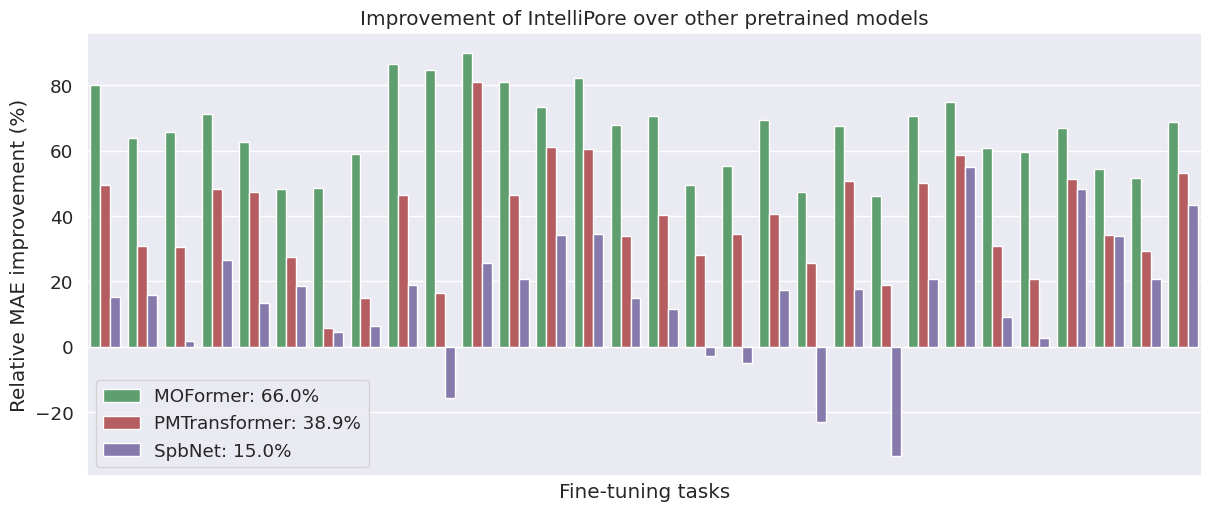

In [154]:
data = delta_dict.copy()
del data['cgcnn']

# Convert to long-form dataframe
rows = []

for model, values in data.items():
    for task_id, value in enumerate(values, start=1):
        rows.append({
            'Task': task_id,
            'Model': model,
            'Improvement': value
        })

df = pd.DataFrame(rows)

fig, ax = plt.subplots(layout='constrained', figsize=[12, 5])

sns.barplot(
    data=df,
    x='Task',
    y='Improvement',
    hue='Model',
    palette=palette[2:5],
    ax=ax,
)

ax.set_ylabel('Relative MAE improvement (%)')
ax.set_xlabel('Fine-tuning tasks')
ax.set_title('Improvement of IntelliPore over other pretrained models')
ax.set_xticks([], [])
ax.get_legend().set_title(None)

# Update legend labels
handles, labels = ax.get_legend_handles_labels()

new_labels = [
    f'{pretty_labels[label]}: {avg_delta_dict[label]:.1f}%'
    for label in labels
]

ax.legend(handles, new_labels, title=None)
plt.savefig('figures/sota_analysis_ungrouped.pdf')

In [155]:
rows

[{'Task': 1, 'Model': 'moformer', 'Improvement': 80.19323651117864},
 {'Task': 2, 'Model': 'moformer', 'Improvement': 63.813115598395804},
 {'Task': 3, 'Model': 'moformer', 'Improvement': 65.61321712552434},
 {'Task': 4, 'Model': 'moformer', 'Improvement': 71.1546270885442},
 {'Task': 5, 'Model': 'moformer', 'Improvement': 62.649176950442566},
 {'Task': 6, 'Model': 'moformer', 'Improvement': 48.189365259055194},
 {'Task': 7, 'Model': 'moformer', 'Improvement': 48.59469166835555},
 {'Task': 8, 'Model': 'moformer', 'Improvement': 59.124183401342144},
 {'Task': 9, 'Model': 'moformer', 'Improvement': 86.44096281454875},
 {'Task': 10, 'Model': 'moformer', 'Improvement': 84.55381841574382},
 {'Task': 11, 'Model': 'moformer', 'Improvement': 89.95079865788473},
 {'Task': 12, 'Model': 'moformer', 'Improvement': 81.11112621273529},
 {'Task': 13, 'Model': 'moformer', 'Improvement': 73.42344612747911},
 {'Task': 14, 'Model': 'moformer', 'Improvement': 82.39761986117962},
 {'Task': 15, 'Model': 'mo

## Relative improvement vs SOTA (grouped)

In [158]:
# Populate MAE of each model
base_models = ['cgcnn', 'moformer', 'pmtransformer', 'spbnet']
ckpt_path = 'from_experiments_pretrain_early_pretrain_lightning_logs_version_0_checkpoints_best.ckpt-to_'
#mae_dict = {model: {'single_uptake': [], 'binary_uptake': [], 'heat': [], 'henry': [], 'selectivity': []} for model in base_models + ['intellipore']}
mae_dict = {model: {'uptake': [], 'heat': [], 'henry': [], 'selectivity': []} for model in base_models + ['intellipore']}

for ds in datasets:
    key = 'null' if ds != 'hmofheat' else '5000'
    for task in set([i.split('-to_')[-1] for i in os.listdir(f'../experiments/evaluate/benchmark/{ds}/')]):
        # Load results for each task
        json_path = f'../experiments/evaluate/benchmark/{ds}/{ckpt_path}{task}/results.json'
        results = load_json(json_path)

        if 'uptake' in pretty_labels[task]:
            #if 'binary' in pretty_labels[task]:
            #    task_type = 'binary_uptake'
            #else:
                #task_type = 'single_uptake'
            task_type = 'uptake'
        elif 'heat' in pretty_labels[task]:
            task_type = 'heat'
        elif 'Henry' in pretty_labels[task]:
            task_type = 'henry'
        else:
            task_type = 'selectivity'
            
        mae_dict['intellipore'][task_type].append(results[key]['0']['test_MeanAbsoluteError'])
        
        for m in base_models:
            mae_dict[m][task_type].append(spbnet_dfs[ds].loc[m, task])

In [159]:
#task_types = ['single_uptake', 'binary_uptake', 'heat', 'henry', 'selectivity']
task_types = ['uptake', 'heat', 'henry', 'selectivity']
delta_dict = {base: {tt: None for tt in task_types} for base in base_models}

for base in base_models:
    for tt in task_types:
        base_model = base
        base_score = np.array(mae_dict[base_model][tt])
        ours_score = np.array(mae_dict['intellipore'][tt])
        delta = -100 * (ours_score - base_score) / base_score
        delta_dict[base][tt] = delta
    
avg_delta_dict = {model: {tt: np.mean(delta_dict[model][tt]) for tt in task_types} for model in delta_dict.keys()}

In [160]:
avg_delta_dict

{'cgcnn': {'uptake': 65.2037727682892,
  'heat': 57.95282260263233,
  'henry': 64.25720261400251,
  'selectivity': 60.38934944529339},
 'moformer': {'uptake': 66.14238326606817,
  'heat': 63.372164976959105,
  'henry': 69.68204040254237,
  'selectivity': 64.82258824939345},
 'pmtransformer': {'uptake': 37.97319363630513,
  'heat': 26.98974165939656,
  'henry': 55.17364315531038,
  'selectivity': 39.46134326377102},
 'spbnet': {'uptake': 7.028460860479002,
  'heat': 15.182777899002323,
  'henry': 41.94040061317587,
  'selectivity': 25.538258400518345}}

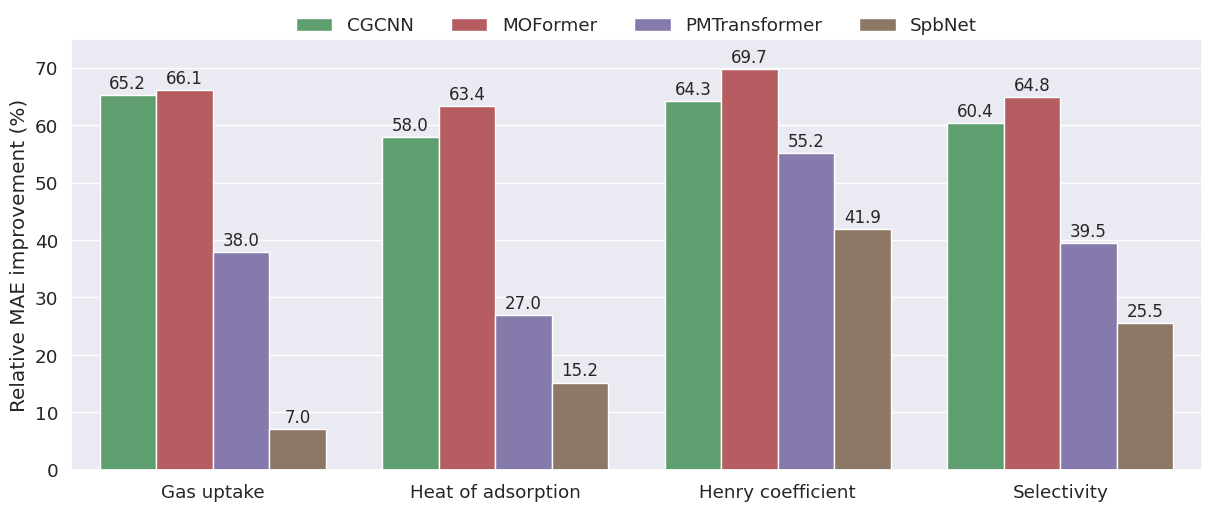

In [162]:
fig, ax = plt.subplots(layout='constrained', figsize=(12, 5))

# Convert to long-form dataframe
rows = []

for model, tt_values in avg_delta_dict.items():
    for tt, value in tt_values.items():
        rows.append({
            'Task type': pretty_labels[tt],
            'Model': pretty_labels[model],
            'Improvement': value
        })
data = pd.DataFrame(rows)

ax = sns.barplot(data, x='Task type', y='Improvement', hue='Model', orient='x', palette=palette[2:6])
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2, fontsize='small')
    
ax.set_xlabel(None)
ax.set_ylabel('Relative MAE improvement (%)')
ax.legend(ncols=4, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.09))
ax.set_ylim(0, 75)

plt.savefig('figures/sota_analysis_grouped.pdf')